# dataset description
## Mean informality per year
**source**: dane

**dataset**: [empleo informal y seguridad social](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/empleo-informal-y-seguridad-social)

# code
## imports

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [17]:
path = "./data/sexo.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [18]:
def get_df_filtered(df: pd.DataFrame, concepto: str) -> pd.Series:
    df_local = df.copy()
    df_f = df_local[
        (df_local["Perspectiva"].eq("Total nacional")) &
        (df_local["Sexo"].eq("Total")) &
        (df_local["Concepto"].eq(concepto))
    ]
    df_avg = df_f.groupby("Fecha")["Valor"].mean().mul(1000)

    return df_avg

df_formal = get_df_filtered(df, "Formal")
df_working = get_df_filtered(df, "Población ocupada")
df_informal = get_df_filtered(df, "Informal") 

formal_pct = df_formal / df_working * 100
informal_pct = df_informal / df_working * 100

## Plot

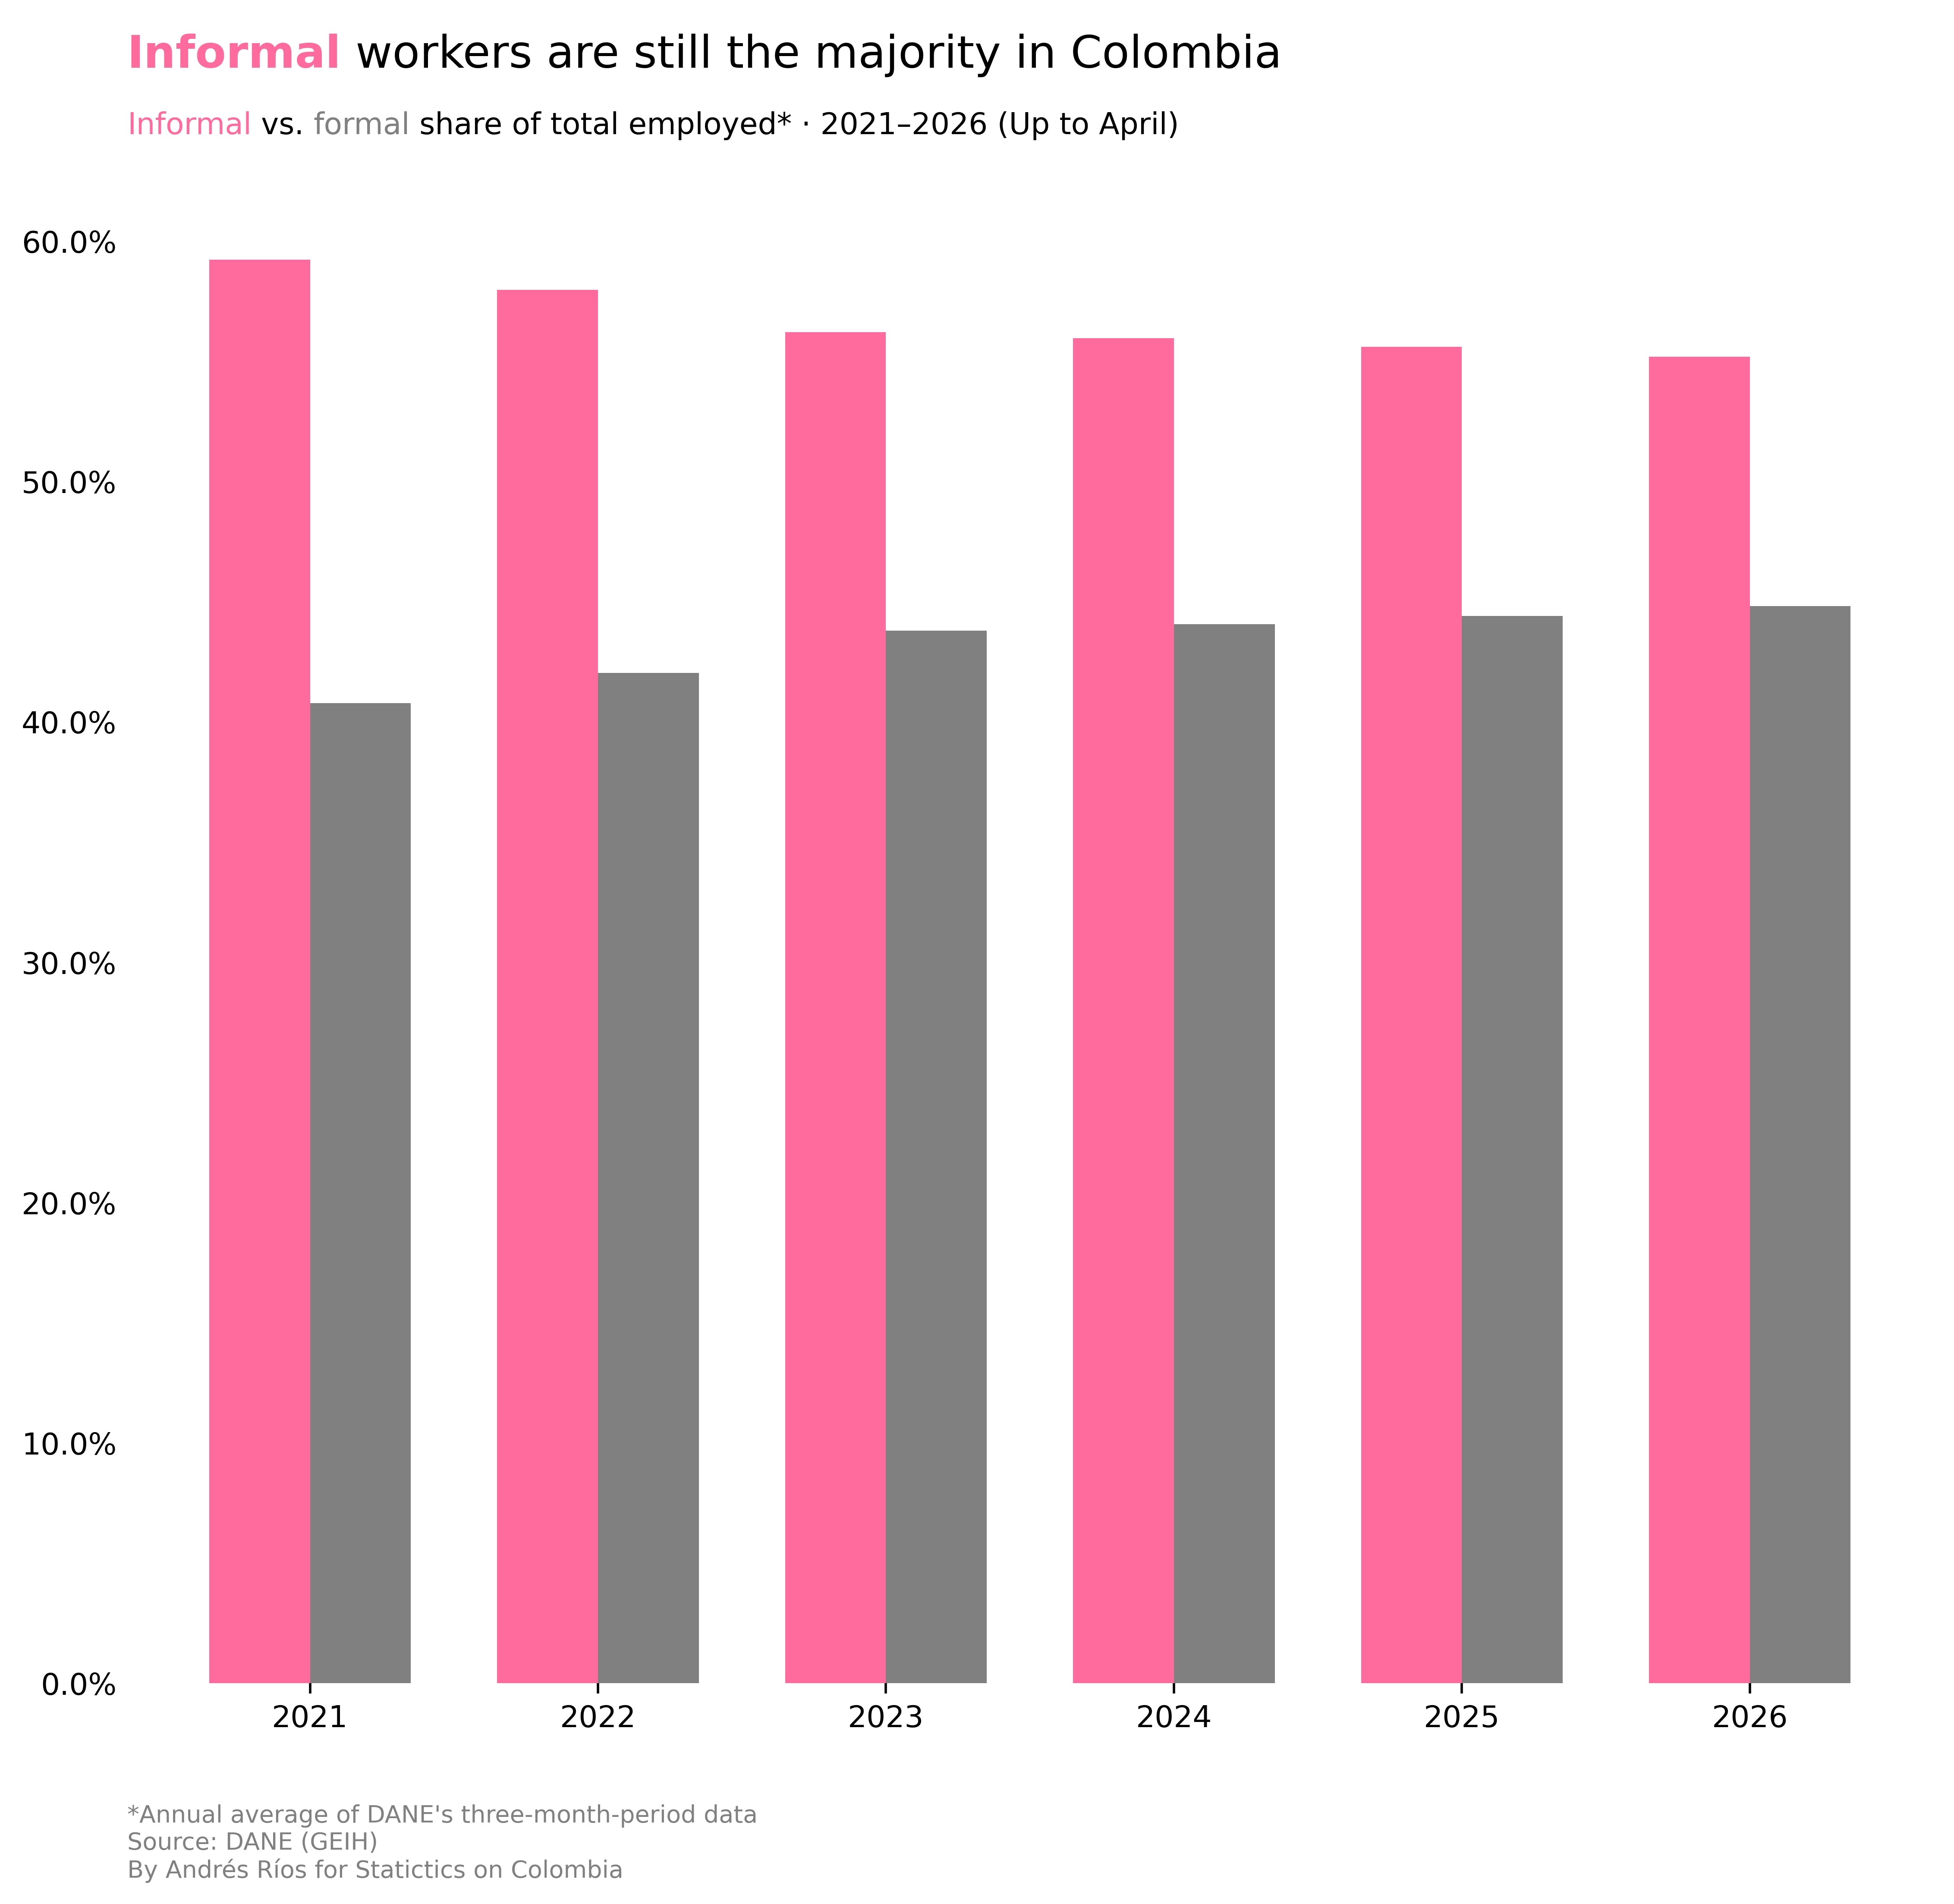

In [19]:
plt.figure(figsize=(10.8, 9), dpi=500)

width = 0.35

informal_color = "#FF6B9D" 

plt.bar(informal_pct.index - width/2, informal_pct.values, width, color=informal_color)
plt.bar(formal_pct.index + width/2, formal_pct.values, width, color="gray")

for side in ["left", "right", "top", "bottom"]:
    plt.gca().spines[side].set_visible(False)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v}%"))

fig_text(
    x=0.125, y=0.96,
    s="<Informal> workers are still the majority in Colombia",
    highlight_textprops=[{"color": informal_color, "weight": "bold"}],
    fontsize=15,
)

fig_text(
    x=0.125, y=0.92,
    s="<Informal> vs. <formal> share of total employed* · 2021–2026 (Up to April)",
    highlight_textprops=[{"color": informal_color},
                         {"color": "gray"}],
    fontsize=10,
)

fig = plt.gcf()
fig.text(
    0.125, 0.01, 
    "*Annual average of DANE's three-month-period data\n"
    "Source: DANE (GEIH)\n"
    "By Andrés Ríos for Statictics on Colombia", 
    fontsize=8, color="gray")

plt.tick_params(axis="y", length=0)

plt.show()